Model loaded! Input shape expected: (None, 224, 224, 3)


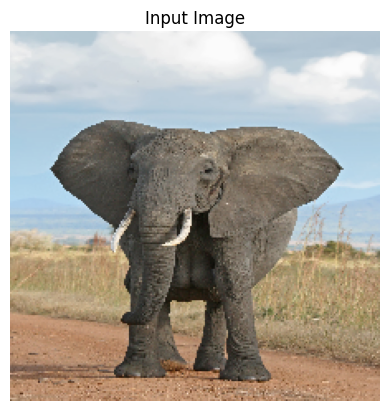

1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step

🔍 Top 5 Predictions:
Class                          Confidence
------------------------------------------
African_elephant                  52.41%  ███████████████
tusker                            17.16%  █████
Indian_elephant                   15.65%  ████
umbrella                           0.57%  
giant_schnauzer                    0.29%  


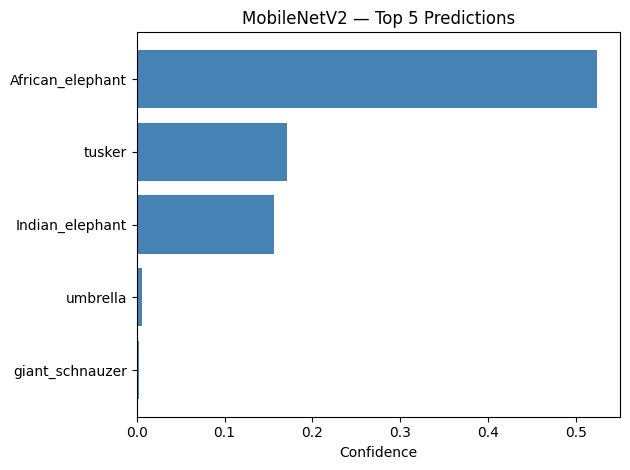

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import urllib.request

# ── 1. Load Pre-trained MobileNetV2 ──────────────────────────────────────────
# weights="imagenet" → loads weights trained on 1000-class ImageNet dataset
# include_top=True  → includes the final classification layer (1000 outputs)
model = MobileNetV2(weights="imagenet", include_top=True)

print("Model loaded! Input shape expected:", model.input_shape)
# Expected: (None, 224, 224, 3) → batch, height, width, RGB channels

# ── 2. Load a Sample Image ───────────────────────────────────────────────────
# Download a sample image (elephant)
# The previous URL was a specific thumbnail size that caused an HTTP 400 error.
# Changing to the full-resolution image URL.
url = "https://upload.wikimedia.org/wikipedia/commons/3/37/African_Bush_Elephant.jpg"

# Create a Request object with a User-Agent header
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
req = urllib.request.Request(url, headers=headers)

# Use urlopen to get the response and urlretrieve to save it
with urllib.request.urlopen(req) as response, open("test_image.jpg", 'wb') as out_file:
    out_file.write(response.read())

# Load and resize to 224x224 (MobileNetV2's required input size)
img = image.load_img("test_image.jpg", target_size=(224, 224))
plt.imshow(img)
plt.title("Input Image")
plt.axis("off")
plt.show()

# ── 3. Preprocess ─────────────────────────────────────────────────────────────
# Convert image → numpy array, add batch dimension [1, 224, 224, 3]
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)      # Model expects a batch

# preprocess_input scales pixels to [-1, 1] range (what MobileNetV2 was trained on)
img_preprocessed = preprocess_input(img_array)

# ── 4. Predict ────────────────────────────────────────────────────────────────
predictions = model.predict(img_preprocessed)
# predictions shape: (1, 1000) → probability for each of 1000 ImageNet classes

# decode_predictions → converts raw scores to human-readable labels
# top=5 → return top 5 most likely classes
top5 = decode_predictions(predictions, top=5)[0]

# ── 5. Display Results ────────────────────────────────────────────────────────
print("\n🔍 Top 5 Predictions:")
print(f"{'Class':<30} {'Confidence':>10}")
print("-" * 42)
for _, label, confidence in top5:
    bar = "█" * int(confidence * 30)
    print(f"{label:<30} {confidence*100:>8.2f}%  {bar}")

# ── 6. Visualize Confidence ───────────────────────────────────────────────────
labels = [p[1] for p in top5]
scores = [p[2] for p in top5]

plt.barh(labels[::-1], scores[::-1], color="steelblue")
plt.xlabel("Confidence")
plt.title("MobileNetV2 — Top 5 Predictions")
plt.tight_layout()
plt.show()